In [ ]:
import numpy as np
import os
import scipy.io
import h5py
import shutil

def carica_blocchi_dati_v73(directory, nome_file, start_idx, end_idx):
    DATI = {}
    percorso_file = os.path.join(directory, nome_file)
    print(f"📂 Caricamento file: {percorso_file} (Immagini {start_idx+1}-{end_idx})")
    
    with h5py.File(percorso_file, 'r') as f:
        N = f['msgData'].shape[0]  # numero di immagini
        end_idx = min(end_idx, N)
        
        for i in range(start_idx, end_idx):
            nome_dato = f"{nome_file}_img_{i}"
            DATI[nome_dato] = {}

            for c in range(11):
                canale = np.array(f['msgData'][i, c, :, :])
                DATI[nome_dato][c + 1] = canale

            DATI[nome_dato][12] = np.array(f['Latitude'][i, :, :])
            DATI[nome_dato][13] = np.array(f['Longitude'][i, :, :])
            DATI[nome_dato]["dpr"] = np.array(f['dprTotalPrecip'][i, :, :])
            DATI[nome_dato]["dayOfYear"] = np.array(f['dayOfYear'][:, i])
            DATI[nome_dato]["iTmOfDay"] = np.array(f['iTmOfDay'][:, i])
                
    print(f"📂 Caricamento completato per {len(DATI)} immagini")
    return DATI

def filtro_geografico(DATI, lat_range, lon_range):
    print(f"📦 Numero di file trovati in DATI: {len(DATI)}")
    FILTERED = {}

    for nome_file in DATI:
        print(f"🔍 Filtro geografico per il file: {nome_file}")
        dati_file = DATI[nome_file]

        if 12 not in dati_file or 13 not in dati_file:
            print(f"  ⚠️  Latitudine o longitudine non trovate nel file {nome_file}, skipping.")
            continue

        latitudine = np.array(dati_file[12])
        longitudine = np.array(dati_file[13])

        if latitudine.shape != longitudine.shape:
            print(f"  ⚠️  Dimensioni di latitudine e longitudine non compatibili, skipping.")
            continue

        mask_lat = (lat_range[0] <= latitudine) & (latitudine <= lat_range[1])
        mask_lon = (lon_range[0] <= longitudine) & (longitudine <= lon_range[1])
        mask = mask_lat & mask_lon

        print(f"  - Filtrato {np.sum(mask)} punti su {mask.size}")

        # Se nessun punto valido, salta
        if not mask.any():
            print(f"  ⚠️  Nessun punto nel range geografico, file {nome_file} ignorato.")
            continue

        dati_filtrati = {}

        for key, array in dati_file.items():
            print(f"    ➤ Chiave: {key} | Forma: {array.shape} | Dimensioni: {array.ndim}")
            try:
                if array.ndim == 2:
                    dati_filtrati[key] = array[mask]
                elif array.ndim == 1:
                    dati_filtrati[key] = array  # day/time: 1 sola info per file
                else:
                    print(f"    ⚠️  Dato con {array.ndim} dimensioni non gestito, escluso.")
            except Exception as e:
                print(f"    ❌ Errore applicando il filtro alla chiave {key}: {e}")

        FILTERED[nome_file] = dati_filtrati
        print(f"  ✅ Dati filtrati per il file {nome_file} salvati.")
    
    return FILTERED

import scipy.io
import os

def salva_dati_filtrati(filtrati, output_dir, nome_file, idx):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
   
    nome_base = f"{os.path.splitext(nome_file)[0]}_image_{idx+1}"
    output_file_mat = os.path.join(output_dir, f"{nome_base}.mat")

    # Salva in formato MATLAB v7.2 (.mat)
    print(f"💾 Salvataggio MAT v7.2 in: {output_file_mat}")
    dati_mat = {}

    # Itera su ogni chiave nei dati filtrati
    for nome_dato, dati in filtrati.items():
        for key, array in dati.items():
            # Aggiungi direttamente la chiave numerica o descrittiva
            if key == 1:
                dati_mat[f'1'] = array
            elif key == 2:
                dati_mat[f'2'] = array
            elif key == 3:
                dati_mat[f'3'] = array
            elif key == 4:
                dati_mat[f'4'] = array
            elif key == 5:
                dati_mat[f'5'] = array
            elif key == 6:
                dati_mat[f'6'] = array
            elif key == 7:
                dati_mat[f'7'] = array
            elif key == 8:
                dati_mat[f'8'] = array
            elif key == 9:
                dati_mat[f'9'] = array
            elif key == 10:
                dati_mat[f'10'] = array
            elif key == 11:
                dati_mat[f'11'] = array
            elif key == 12:
                dati_mat[f'12'] = array
            elif key == 13:
                dati_mat[f'13'] = array
            elif key == "dpr":
                dati_mat[f'dpr'] = array
            elif key == "dayOfYear":
                dati_mat[f'dayOfYear'] = array
            elif key == "iTmOfDay":
                dati_mat[f'iTmOfDay'] = array
            else:
                # Per altre chiavi non numeriche
                dati_mat[f'{key}'] = array

    # Salvataggio del file .mat
    scipy.io.savemat(output_file_mat, dati_mat, do_compression=True)

    print(f"✅ Dati salvati correttamente in formato .mat:\n   📁 {output_file_mat}")
    
def processa_gruppi(directory, lat_range, lon_range, output_dir, group_size=100):
    
    # 🧹 Pulizia della cartella di output prima di iniziare
    print(f"🧹 Pulizia della cartella di output: {output_dir}")
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir)
    os.makedirs(output_dir)
    
    print(f"📁 Directory specificata: {directory}")
    if not os.path.exists(directory):
        print(f"❌ La directory {directory} non esiste!")
        return {}

    file_list = [f for f in os.listdir(directory) if f.endswith('.mat')]
    print(f"📄 File trovati: {file_list}")
    num_files = len(file_list)
    print(f"📦 Numero di file trovati: {num_files}")

    FILTERED = {}

    for file_name in file_list:
        print(f"📂 Processando il file {file_name}...")

        percorso_file = os.path.join(directory, file_name)
        with h5py.File(percorso_file, 'r') as f:
            N = f['msgData'].shape[0]  # numero di immagini
            print(f"📷 Numero totale di immagini: {N}")

        for start_idx in range(0, N, group_size):
            end_idx = start_idx + group_size
            print(f"📂 Caricamento immagini {start_idx+1}-{min(end_idx, N)} su {N}...")

            # Carica un blocco di dati (gruppo di immagini)
            DATI_blocco = carica_blocchi_dati_v73(directory, file_name, start_idx, end_idx)
            print(f"✅ Blocchi caricati: {len(DATI_blocco)}")

            # Applica il filtro geografico
            dati_filtrati = filtro_geografico(DATI_blocco, lat_range, lon_range)
            print(f"✅ Blocchi filtrati: {len(dati_filtrati)}")

            # Salva ogni immagine separatamente
            for idx, dati in enumerate(dati_filtrati):
                salva_dati_filtrati(dati_filtrati, output_dir, file_name, start_idx + idx)

            # Aggiungi i dati filtrati al dizionario finale
            FILTERED.update(dati_filtrati)

    print(f"✅ Totale immagini filtrate: {len(FILTERED)}")
    return FILTERED

# Impostazioni directory e file
directory = 'C:/Users/user/Documents/TESI/datigrezzi/DATI_grezzi_2020'
output_dir = 'C:/Users/user/Documents/TESI/datigrezzi/DATI_grezzi_2020/OUTPUT_1'
lat_range = (35, 50)
lon_range = (-10, 25)

# Avvio del processo
processa_gruppi(directory, lat_range, lon_range, output_dir)

In [ ]:
############## USO QUESTO!!!! ###############

import numpy as np
import os
import scipy.io
import h5py
import shutil

def carica_blocchi_dati_v73(directory, nome_file, start_idx, end_idx):
    DATI = {}
    percorso_file = os.path.join(directory, nome_file)
    print(f"📂 Caricamento file: {percorso_file} (Immagini {start_idx+1}-{end_idx})")
    
    with h5py.File(percorso_file, 'r') as f:
        N = f['msgData'].shape[0]  # numero di immagini
        end_idx = min(end_idx, N)
        
        for i in range(start_idx, end_idx):
            nome_dato = f"{nome_file}_img_{i}"
            DATI[nome_dato] = {}

            for c in range(11):
                canale = np.array(f['msgData'][i, c, :, :])
                DATI[nome_dato][c + 1] = canale

            DATI[nome_dato][12] = np.array(f['Latitude'][i, :, :])
            DATI[nome_dato][13] = np.array(f['Longitude'][i, :, :])
            DATI[nome_dato]["dpr"] = np.array(f['dprTotalPrecip'][i, :, :])
            DATI[nome_dato]["dayOfYear"] = np.array(f['dayOfYear'][:, i])
            DATI[nome_dato]["iTmOfDay"] = np.array(f['iTmOfDay'][:, i])
                
    print(f"📂 Caricamento completato per {len(DATI)} immagini")
    return DATI

def filtro_geografico(DATI, lat_range, lon_range):
    print(f"📦 Numero di file trovati in DATI: {len(DATI)}")
    FILTERED = {}

    for nome_file in DATI:
        print(f"🔍 Controllo geografico per il file: {nome_file}")
        dati_file = DATI[nome_file]

        if 12 not in dati_file or 13 not in dati_file:
            print(f"  ⚠️  Latitudine o longitudine non trovate nel file {nome_file}, skipping.")
            continue

        latitudine = np.array(dati_file[12])
        longitudine = np.array(dati_file[13])

        if latitudine.shape != longitudine.shape:
            print(f"  ⚠️  Dimensioni di latitudine e longitudine non compatibili, skipping.")
            continue

        mask_lat = (lat_range[0] <= latitudine) & (latitudine <= lat_range[1])
        mask_lon = (lon_range[0] <= longitudine) & (longitudine <= lon_range[1])
        mask = mask_lat & mask_lon

        if not mask.any():
            print(f"  ⚠️  Nessun punto nel range geografico, file {nome_file} ignorato.")
            continue  # scarta l'intera immagine

        # ✅ Se almeno un punto è dentro il range, tieni tutto il file
        FILTERED[nome_file] = dati_file
        print(f"  ✅ File {nome_file} accettato (almeno un punto valido).")

    return FILTERED

import scipy.io
import os
from scipy.io import savemat
 
def salva_dati_filtrati(dati, output_dir, nome_file, idx, gia_visti):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    giorno = int(dati['dayOfYear'])
    ora = int(dati['iTmOfDay'])
    chiave = (giorno, ora)

    if chiave in gia_visti:
        print(f"⚠️ Immagine già salvata: giorno {giorno}, ora {ora}")
        return
    gia_visti.add(chiave)

    nome_base = f"{os.path.splitext(nome_file)[0]}_DOY{giorno}_TIME{ora}"
    output_file_mat = os.path.join(output_dir, f"{nome_base}.mat")

    # Salva in formato MATLAB v7.2 (.mat)
    print(f"💾 Salvataggio MAT v7.2 in: {output_file_mat}")
    dati_mat = {}

    for key, array in dati.items():
        if key == 1:
            dati_mat['1'] = array
        elif key == 2:
            dati_mat['2'] = array
        elif key == 3:
            dati_mat['3'] = array
        elif key == 4:
            dati_mat['4'] = array
        elif key == 5:
            dati_mat['5'] = array
        elif key == 6:
            dati_mat['6'] = array
        elif key == 7:
            dati_mat['7'] = array
        elif key == 8:
            dati_mat['8'] = array
        elif key == 9:
            dati_mat['9'] = array
        elif key == 10:
            dati_mat['10'] = array
        elif key == 11:
            dati_mat['11'] = array
        elif key == 12:
            dati_mat['12'] = array
        elif key == 13:
            dati_mat['13'] = array
        elif key == "dpr":
            dati_mat['dpr'] = array
        elif key == "dayOfYear":
            dati_mat['dayOfYear'] = array
        elif key == "iTmOfDay":
            dati_mat['iTmOfDay'] = array
        else:
            dati_mat[str(key)] = array

    savemat(output_file_mat, dati_mat)
    
def processa_gruppi(directory, lat_range, lon_range, output_dir, group_size=100):
    
    # 🧹 Pulizia della cartella di output prima di iniziare
    print(f"🧹 Pulizia della cartella di output: {output_dir}")
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir)
    os.makedirs(output_dir)
    
    print(f"📁 Directory specificata: {directory}")
    if not os.path.exists(directory):
        print(f"❌ La directory {directory} non esiste!")
        return {}

    file_list = [f for f in os.listdir(directory) if f.endswith('.mat')]
    print(f"📄 File trovati: {file_list}")
    num_files = len(file_list)
    print(f"📦 Numero di file trovati: {num_files}")

    FILTERED = {}

    for file_name in file_list:
        print(f"📂 Processando il file {file_name}...")

        percorso_file = os.path.join(directory, file_name)
        with h5py.File(percorso_file, 'r') as f:
            N = f['msgData'].shape[0]  # numero di immagini
            print(f"📷 Numero totale di immagini: {N}")

        for start_idx in range(0, N, group_size):
            end_idx = start_idx + group_size
            print(f"📂 Caricamento immagini {start_idx+1}-{min(end_idx, N)} su {N}...")

            # Carica un blocco di dati (gruppo di immagini)
            DATI_blocco = carica_blocchi_dati_v73(directory, file_name, start_idx, end_idx)
            print(f"✅ Blocchi caricati: {len(DATI_blocco)}")

            # Applica il filtro geografico
            dati_filtrati = filtro_geografico(DATI_blocco, lat_range, lon_range)
            print(f"✅ Blocchi filtrati: {len(dati_filtrati)}")

            # Salva ogni immagine separatamente
            for idx, (nome_img, dati) in enumerate(dati_filtrati.items()):
                salva_dati_filtrati(dati, output_dir, file_name, start_idx + idx, gia_visti)
            # Aggiungi i dati filtrati al dizionario finale
            FILTERED.update(dati_filtrati)

    print(f"✅ Totale immagini filtrate: {len(FILTERED)}")
    return FILTERED

# Impostazioni directory e file
directory = 'C:/Users/user/Documents/TESI/datigrezzi/DATI_grezzi_2020'
output_dir = 'C:/Users/user/Documents/TESI/datigrezzi/DATI_grezzi_2020/OUTPUT_1'
lat_range = (35, 50)
lon_range = (-10, 25)

gia_visti = set()  # <- QUI
# Avvio del processo
processa_gruppi(directory, lat_range, lon_range, output_dir)

In [1]:
import numpy as np
import os
import scipy.io
import h5py
import shutil

cartella_output= 'C:/Users/user/Documents/TESI/datigrezzi/DATI_grezzi_2020/OUTPUT_1'

# Carica un file specifico dalla cartella OUTPUT_1
file_scelto = "msgDprImerg_CalFlipCln_2020_image_1.mat"  # Sostituisci con il nome del file che vuoi caricare
path_file_scelto = os.path.join(cartella_output, file_scelto)

# Carica il file .mat
dati_file = scipy.io.loadmat(path_file_scelto)

# Stampa le chiavi disponibili nel file
# Stampa le chiavi disponibili nel dizionario dei dati
print(f"Chiavi disponibili nel file {file_scelto}: {list(dati_file.keys())}")

# Lista delle chiavi che vogliamo controllare
chiavi_da_controllare = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, "dpr", "dayOfYear", "iTmOfDay"]

# Verifica e stampa il contenuto per ciascuna chiave
for chiave in chiavi_da_controllare:
    if str(chiave) in dati_file:
        print(f"Chiave {chiave} trovata! Tipo: {type(dati_file[str(chiave)])}")
        print(f"Contenuto della chiave {chiave} (primi 5 elementi): {dati_file[str(chiave)][:5]}")
    else:
        print(f"Chiave {chiave} non trovata nel file.")
else:
    print("Chiave 11 non trovata nel file.")

FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/user/Documents/TESI/datigrezzi/DATI_grezzi_2020/OUTPUT_1\\msgDprImerg_CalFlipCln_2020_image_1.mat'

In [ ]:
import os
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Percorso al file .mat che vuoi ispezionare
file_path = "C:/Users/user/Documents/TESI/datigrezzi/DATI_grezzi_2020/OUTPUT_1/msgDprImerg_CalFlipCln_2020_DOY312_TIME88.mat"

# Carica il file .mat
data = scipy.io.loadmat(file_path)

# Stampa le chiavi principali
print(f"Chiavi principali nel file .mat: {list(data.keys())}")

# Stampa tutte le variabili nel file
for key in data.keys():
    print(f"Chiave: {key}")
    print(f"  Tipo: {type(data[key])}")
    print(f"  Forma: {getattr(data[key], 'shape', 'N/A')}")
    print(f"  Contenuto (primi 5 elementi, se possibile): {data[key][:5] if isinstance(data[key], np.ndarray) else 'Non è un array'}")

# Percorso alla cartella OUTPUT_1
cartella_output = 'C:/Users/user/Documents/TESI/datigrezzi/DATI_grezzi_2020/OUTPUT_1'
lat_totali = []
lon_totali = []

print("🔍 Avvio analisi file in OUTPUT_1...\n")

for nome_file in os.listdir(cartella_output):
    if nome_file.endswith('.mat'):
        path_file = os.path.join(cartella_output, nome_file)
        try:
            dati = scipy.io.loadmat(path_file)
            chiavi = dati.keys()

            lat = dati.get('12')
            lon = dati.get('13')

            if lat is not None and lon is not None:
                lat_flat = lat.flatten()
                lon_flat = lon.flatten()
                num_punti = len(lat_flat)

                print(f"✔️  {nome_file}")
                print(f"   - Chiavi disponibili: {list(chiavi)}")
                print(f"   - Lat shape: {lat.shape} | Lon shape: {lon.shape}")
                print(f"   - Range lat: {np.nanmin(lat):.2f} → {np.nanmax(lat):.2f}")
                print(f"   - Range lon: {np.nanmin(lon):.2f} → {np.nanmax(lon):.2f}")
                print(f"   - Punti totali: {num_punti}\n")

                lat_totali.extend(lat_flat)
                lon_totali.extend(lon_flat)
            else:
                print(f"⚠️  {nome_file} - latitudine o longitudine non trovate.\n")
        except Exception as e:
            print(f"❌ Errore nel file {nome_file}: {e}\n")

# Converti in array NumPy
lat_totali = np.array(lat_totali)
lon_totali = np.array(lon_totali)

print(f"🧮 Totale punti caricati: {len(lat_totali)}")

# Filtra eventuali NaN
validi = ~np.isnan(lat_totali) & ~np.isnan(lon_totali)
lat_validi = lat_totali[validi]
lon_validi = lon_totali[validi]

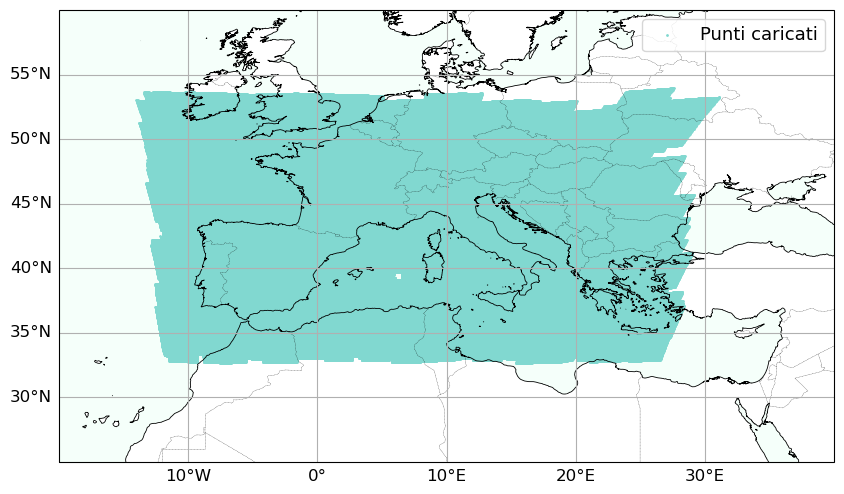

In [22]:
# === PLOT con CARTOPY ===
plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Aggiungi caratteristiche geografiche
ax.add_feature(cfeature.LAND, facecolor='white')
ax.add_feature(cfeature.OCEAN, facecolor='mintcream')
ax.coastlines(resolution='10m', linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linestyle='--', linewidth=0.2)
#ax.add_feature(cfeature.LAKES, facecolor='lightblue')
#ax.add_feature(cfeature.RIVERS, edgecolor='blue')

# Griglia con etichette
gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 12}
gl.ylabel_style = {'size': 12}

# Limiti della mappa (Europa)
ax.set_extent([-20, 40, 25, 60], crs=ccrs.PlateCarree())

# Aggiungi i tuoi punti
ax.scatter(lon_validi, lat_validi, s=1, color='#81D8D0', alpha=1, transform=ccrs.PlateCarree(), label='Punti caricati')

#plt.title('Geographic map of the loaded points', pad =18, fontsize=16)
plt.legend(fontsize=13)
plt.show()

In [9]:
import h5py
import numpy as np

def esplora_file_mat_v73(percorso_file):
    print(f"\n📂 Esplorazione del file HDF5 (v7.3): {percorso_file}\n")
    
    try:
        with h5py.File(percorso_file, 'r') as file:
            def esplora_gruppo(gruppo, prefix=""):
                for chiave in gruppo:
                    oggetto = gruppo[chiave]
                    path = prefix + '/' + chiave if prefix else chiave

                    if isinstance(oggetto, h5py.Group):
                        print(f"📁 Gruppo: {path}/")
                        esplora_gruppo(oggetto, path)
                    elif isinstance(oggetto, h5py.Dataset):
                        print(f"📄 Dataset: {path}")
                        print(f"   - Tipo: {oggetto.dtype}")
                        print(f"   - Forma: {oggetto.shape}")

                        print(f"🔎 Nome chiave: {path}")  # 👈 DEBUG

                        dati = oggetto[()]
                        
                        if "dayofyear" in path.lower() or "itmoofday" in path.lower():
                            dati_flat = dati.flatten()
                            print(f"   - Valori unici (max 10): {np.unique(dati_flat)[:10]}")
                            print(f"   - Min: {np.min(dati_flat)}, Max: {np.max(dati_flat)}")
                            print(f"   - Campione: {dati_flat[:10]}")
                        elif oggetto.size <= 20:
                            print(f"   - Valori: {dati}")
                        elif oggetto.ndim == 1:
                            print(f"   - Primi 10 valori: {dati[:10]}")
                        elif oggetto.ndim == 2:
                            print(f"   - [0:5, 0:5]:\n{dati[:5, :5]}")
                        elif oggetto.ndim == 3:
                            print(f"   - [0, :5, :5]:\n{dati[0, :5, :5]}")

                        print("-" * 50)
                    else:
                        print(f"❓ Oggetto sconosciuto: {path}")

            esplora_gruppo(file)

    except Exception as e:
        print(f"❌ Errore durante la lettura del file: {e}")